In [ ]:
"""
CoTracker Baseline: Random Initialization on Bear Video
Initializes 500 random points in first frame and tracks them through the video.
Computes particle-based accuracy metrics as in dino_tracking.py
"""

import os
import sys
import numpy as np
import torch
import cv2
from glob import glob
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.insert(0, '/home/esli/GenParticles_NeurIPS')
from genparticles.evaluation import get_segmentation_mask

# ============================================================================
# Configuration
# ============================================================================

VIDEO_NAME = "bear"
DAVIS_RGB_PATH = "/home/esli/GenMatter/assets/cvpr_deformable_experiment/frames"
DAVIS_SEGMASKS_PATH = "/home/esli/GenMatter/assets/cvpr_deformable_experiment/segmasks"
NUM_RANDOM_POINTS = 500
FOCAL_LENGTH = 520.0
RANDOM_SEED = 42

# Set random seeds
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Configuration loaded")

Configuration loaded


In [2]:
# ============================================================================
# Load Video Frames
# ============================================================================

print(f"Loading {VIDEO_NAME} video frames...")
rgb_dir = os.path.join(DAVIS_RGB_PATH, VIDEO_NAME)
rgb_files = sorted(glob(os.path.join(rgb_dir, "*.jpg")))

if len(rgb_files) == 0:
    raise ValueError(f"No RGB frames found for {VIDEO_NAME}")

# Get target dimensions from 3D motion data (same as dino_tracking.py)
motion_data_path = "/home/esli/GenMatter/assets/cvpr_deformable_experiment/npzs"
motion_data = np.load(os.path.join(motion_data_path, f"{VIDEO_NAME}_3d_motion.npz"))
positions = motion_data['points_3d']
T, img_height, img_width, _ = positions.shape
img_dims = (img_height, img_width)
print(f"Target dimensions from 3D motion data: {img_dims}")

# Load all frames and resize to match 3D motion data
frames_list = []
for rgb_file in rgb_files[:T]:  # Only load frames that have 3D motion data
    frame = cv2.imread(rgb_file)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Resize to match 3D motion data dimensions
    frame = cv2.resize(frame, (img_width, img_height), interpolation=cv2.INTER_LINEAR)
    frames_list.append(frame)

frames_np = np.stack(frames_list, axis=0)  # T, H, W, C
print(f"Loaded {len(frames_np)} frames with shape {frames_np.shape}")

# Load first frame segmentation mask
first_frame_seg = get_segmentation_mask(
    VIDEO_NAME, 0, DAVIS_SEGMASKS_PATH, img_dims=img_dims, flatten=True
)
print(f"Loaded segmentation mask with {np.sum(first_frame_seg)} foreground pixels")

Loading bear video frames...


Target dimensions from 3D motion data: (520, 960)
Loaded 81 frames with shape (81, 520, 960, 3)
Loaded segmentation mask with 59948 foreground pixels


In [3]:
# ============================================================================
# Initialize Random Points in First Frame
# ============================================================================

print(f"\nInitializing {NUM_RANDOM_POINTS} random points in first frame...")

# Generate random 2D coordinates in first frame
# CoTracker expects coordinates in (x, y) format, range [0, width-1] x [0, height-1]
random_x = np.random.uniform(0, img_width - 1, size=NUM_RANDOM_POINTS)
random_y = np.random.uniform(0, img_height - 1, size=NUM_RANDOM_POINTS)

# Stack to create Nx2 array of (x, y) coordinates
random_points = np.stack([random_x, random_y], axis=1)  # Shape: (N, 2)

print(f"Random points shape: {random_points.shape}")
print(f"Random points range: x=[{random_x.min():.2f}, {random_x.max():.2f}], y=[{random_y.min():.2f}, {random_y.max():.2f}]")


Initializing 1000 random points in first frame...
Random points shape: (1000, 2)
Random points range: x=[4.44, 958.73], y=[1.67, 518.70]


In [4]:
# ============================================================================
# Run CoTracker
# ============================================================================

print("\nLoading CoTracker model...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Prepare video tensor for CoTracker: B, T, C, H, W
video = torch.tensor(frames_np).permute(0, 3, 1, 2)[None].float().to(device)
print(f"Video tensor shape: {video.shape}")

# Load CoTracker model
cotracker = torch.hub.load("facebookresearch/co-tracker", "cotracker3_offline").to(device)
print("CoTracker model loaded successfully")

# Prepare queries for CoTracker
# Format: (B, N, 3) where each query is [t, x, y]
# t=0 means all points are initialized in first frame
queries = torch.zeros((1, NUM_RANDOM_POINTS, 3), device=device)
queries[0, :, 0] = 0  # All points at t=0
queries[0, :, 1] = torch.tensor(random_points[:, 0], device=device)  # x coordinates
queries[0, :, 2] = torch.tensor(random_points[:, 1], device=device)  # y coordinates

print(f"\nRunning CoTracker on {NUM_RANDOM_POINTS} points...")
print(f"Queries shape: {queries.shape}")

with torch.no_grad():
    pred_tracks, pred_visibility = cotracker(video, queries=queries)

# pred_tracks: (B, T, N, 2) - (x, y) coordinates for each point at each time
# pred_visibility: (B, T, N) - visibility mask for each point at each time

print(f"Tracking complete!")
print(f"pred_tracks shape: {pred_tracks.shape}")
print(f"pred_visibility shape: {pred_visibility.shape}")

# Convert to numpy
pred_tracks_np = pred_tracks[0].cpu().numpy()  # (T, N, 2)
pred_visibility_np = pred_visibility[0].cpu().numpy()  # (T, N)

print(f"Tracks numpy shape: {pred_tracks_np.shape}")
print(f"Visibility numpy shape: {pred_visibility_np.shape}")


Loading CoTracker model...
Using device: cuda
Video tensor shape: torch.Size([1, 81, 3, 520, 960])


Using cache found in /home/esli/.cache/torch/hub/facebookresearch_co-tracker_main


CoTracker model loaded successfully

Running CoTracker on 1000 points...
Queries shape: torch.Size([1, 1000, 3])
Tracking complete!
pred_tracks shape: torch.Size([1, 81, 1000, 2])
pred_visibility shape: torch.Size([1, 81, 1000])
Tracks numpy shape: (81, 1000, 2)
Visibility numpy shape: (81, 1000)


In [5]:
# ============================================================================
# Compute Particle-Based Accuracy Metrics
# ============================================================================

print("\n" + "="*80)
print("Computing particle-based accuracy metrics...")
print("="*80)

# Identify object vs background particles in frame 0
frame0_coords = pred_tracks_np[0]  # (N, 2) - (x, y)
x_coords = np.clip(frame0_coords[:, 0].astype(int), 0, img_width - 1)
y_coords = np.clip(frame0_coords[:, 1].astype(int), 0, img_height - 1)
pixel_indices_frame0 = y_coords * img_width + x_coords

# Classify particles as object or background based on first frame mask
object_particles_frame0 = first_frame_seg[pixel_indices_frame0] == 1
background_particles_frame0 = first_frame_seg[pixel_indices_frame0] == 0

n_object_particles = np.sum(object_particles_frame0)
n_background_particles = np.sum(background_particles_frame0)

print(f"\nFrame 0 statistics:")
print(f"  Object particles: {n_object_particles}")
print(f"  Background particles: {n_background_particles}")
print(f"  Total: {len(object_particles_frame0)}")


Computing particle-based accuracy metrics...

Frame 0 statistics:
  Object particles: 118
  Background particles: 882
  Total: 1000


In [6]:
# ============================================================================
# Track accuracy over time
# ============================================================================
# 
# EVALUATION METHODOLOGY - CRITICAL NOTE:
# 
# We evaluate ALL particles (visible AND occluded) against the segmentation mask.
# This tests 3D OBJECT-CENTRIC TRACKING, not pure 2D point tracking.
#
# WHY THIS IS THE CORRECT EVALUATION:
#
# 1. WHAT WE'RE TESTING:
#    - Can the tracker maintain particles "attached" to 3D objects over time?
#    - This is fundamentally different from 2D point tracking (e.g., tracking a texture patch)
#    - GenParticles represents 3D matter; we're testing if CoTracker can do the same
#
# 2. WHY OCCLUSION DOESN'T MATTER FOR THIS METRIC:
#    - Our videos have ONLY SELF-OCCLUSION (object parts occluding other parts of same object)
#    - When a bear's paw goes behind its body, it's still part of the bear
#    - The segmentation mask = 2D projection of the entire 3D object (visible + occluded)
#    - Therefore: An occluded particle should STILL lie within the object's segmask
#
# 3. WHAT THIS TESTS:
#    - Does the tracker maintain object permanence? (particle stays with its object)
#    - Does it understand 3D structure? (occluded parts are still part of the object)
#    - If a tracker marks a point "occluded" but tracks it outside the segmask,
#      that's a FAILURE of 3D object representation, not just occlusion handling
#
# 4. CONTRAST WITH PURE 2D TRACKING:
#    - Pure 2D tracking: "Where is this pixel pattern?"
#    - 3D object tracking: "Where is this piece of matter?"
#    - For 3D matter, occlusion doesn't change which object you belong to
#
# 5. SPECIAL CASE - FALSE POSITIVES:
#    - Background particles that are marked as occluded AND in the mask are NOT counted as FP
#    - Rationale: If CoTracker says "this is occluded", it's acknowledging uncertainty
#    - We only penalize confident predictions that are wrong (visible particles in wrong place)
#    - This is fair: we test object tracking for object particles (all counted),
#      but for background we only count when tracker is confident (visible)
#
# BOTTOM LINE: We're testing if CoTracker can represent 3D objects (like GenParticles),
# not just track 2D pixels. Segmask overlap is the right metric for this.

false_negative_rates = []
false_positive_rates = []

for frame_idx in range(len(pred_tracks_np)):
    frame_coords = pred_tracks_np[frame_idx]  # (N, 2)
    visibility = pred_visibility_np[frame_idx]  # (N,)

    # Get current segmentation mask
    seg_mask = get_segmentation_mask(
        VIDEO_NAME, frame_idx, DAVIS_SEGMASKS_PATH, img_dims=img_dims, flatten=True
    )

    # Project coordinates to pixels (for ALL particles, visible or not)
    x_2d = np.clip(frame_coords[:, 0].astype(int), 0, img_width - 1)
    y_2d = np.clip(frame_coords[:, 1].astype(int), 0, img_height - 1)
    pixel_indices = y_2d * img_width + x_2d

    # For object particles: count how many are still in the mask (TP)
    # Count ALL object particles, regardless of visibility/occlusion
    tp_count = 0
    for i in np.where(object_particles_frame0)[0]:
        pixel_idx = pixel_indices[i]
        if pixel_idx < len(seg_mask) and seg_mask[pixel_idx]:
            tp_count += 1

    # False negatives: object particles that left the mask
    # These are particles that failed to stay "attached" to their 3D object
    fn_count = n_object_particles - tp_count
    fn_rate = (fn_count / n_object_particles) * 100 if n_object_particles > 0 else 0.0

    # For background particles: count how many entered the mask (FP)
    # IMPORTANT: Only count VISIBLE background particles
    # If a background particle is occluded and happens to be in the mask,
    # that's not a confident wrong prediction - the tracker is uncertain about it
    fp_count = 0
    for i in np.where(background_particles_frame0)[0]:
        # Only count if visible (not occluded)
        if visibility[i] > 0.5:
            pixel_idx = pixel_indices[i]
            if pixel_idx < len(seg_mask) and seg_mask[pixel_idx]:
                fp_count += 1

    fp_rate = (fp_count / n_background_particles) * 100 if n_background_particles > 0 else 0.0

    false_negative_rates.append(fn_rate)
    false_positive_rates.append(fp_rate)

mean_fn_rate = np.mean(false_negative_rates)
mean_fp_rate = np.mean(false_positive_rates)

print(f"\n" + "="*80)
print("RESULTS: 3D Object-Centric Tracking Evaluation")
print("="*80)
print(f"Video: {VIDEO_NAME}")
print(f"Number of points tracked: {NUM_RANDOM_POINTS}")
print(f"Number of frames: {len(pred_tracks_np)}")
print(f"\nParticle-Based Error Rates:")
print(f"  Mean FN Rate: {mean_fn_rate:.2f}%  (object particles leaving mask)")
print(f"  Mean FP Rate: {mean_fp_rate:.2f}%  (background particles entering mask)")
print(f"  Object particles (frame 0): {n_object_particles}")
print(f"  Background particles (frame 0): {n_background_particles}")
print(f"\nEvaluation methodology:")
print(f"  - FN: ALL object particles counted (visible + occluded)")
print(f"  - FP: Only VISIBLE background particles counted")
print(f"  - Rationale: Occluded = tracker is uncertain, only penalize confident errors")
print(f"See comments above for detailed methodology explanation.")


RESULTS: 3D Object-Centric Tracking Evaluation
Video: bear
Number of points tracked: 1000
Number of frames: 81

Particle-Based Error Rates:
  Mean FN Rate: 3.00%  (object particles leaving mask)
  Mean FP Rate: 0.15%  (background particles entering mask)
  Object particles (frame 0): 118
  Background particles (frame 0): 882

Evaluation methodology:
  - FN: ALL object particles counted (visible + occluded)
  - FP: Only VISIBLE background particles counted
  - Rationale: Occluded = tracker is uncertain, only penalize confident errors
See comments above for detailed methodology explanation.



Generating error rate plot...


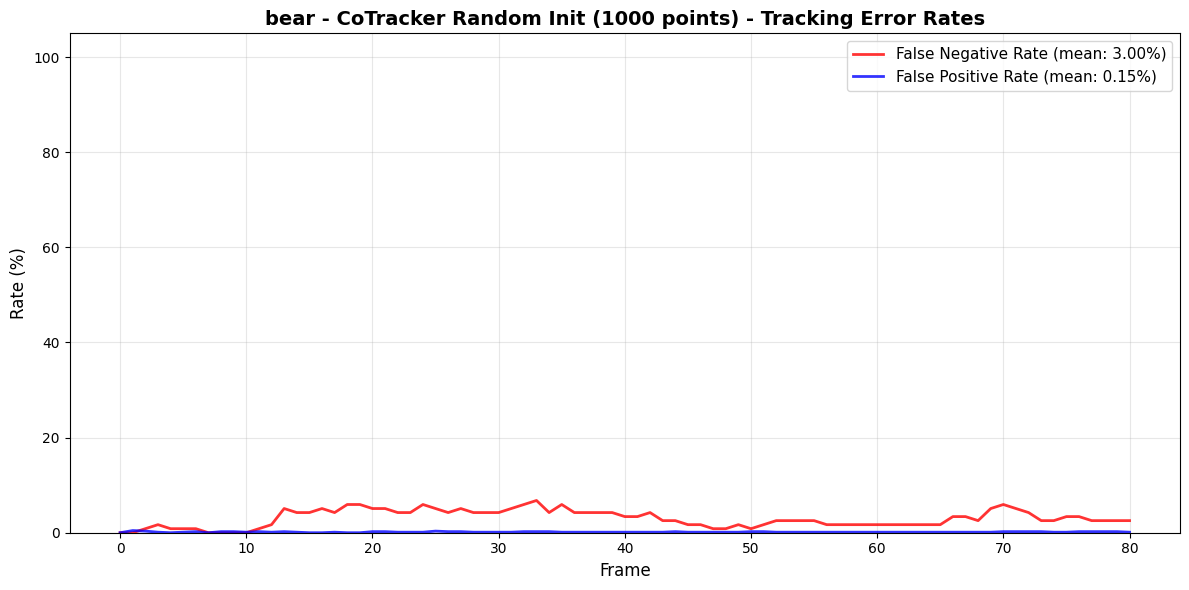

Saved plot to: /home/esli/GenParticles_NeurIPS/cotracker_baseline/bear_cotracker_random_init_error_rates.png


<Figure size 640x480 with 0 Axes>

In [7]:
# ============================================================================
# Plot Error Rates
# ============================================================================

print("\nGenerating error rate plot...")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(false_negative_rates)), false_negative_rates, linewidth=2,
        color='red', label=f'False Negative Rate (mean: {mean_fn_rate:.2f}%)', alpha=0.8)
ax.plot(range(len(false_positive_rates)), false_positive_rates, linewidth=2,
        color='blue', label=f'False Positive Rate (mean: {mean_fp_rate:.2f}%)', alpha=0.8)
ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_title(f'{VIDEO_NAME} - CoTracker Random Init ({NUM_RANDOM_POINTS} points) - Tracking Error Rates',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 105])
plt.tight_layout()
plt.show()

output_dir = "/home/esli/GenParticles_NeurIPS/cotracker_baseline"
os.makedirs(output_dir, exist_ok=True)
plot_path = os.path.join(output_dir, f"{VIDEO_NAME}_cotracker_random_init_error_rates.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Saved plot to: {plot_path}")

In [8]:
# ============================================================================
# Save Results
# ============================================================================

results = {
    'video_name': VIDEO_NAME,
    'num_points': NUM_RANDOM_POINTS,
    'num_frames': len(pred_tracks_np),
    'n_object_particles': int(n_object_particles),
    'n_background_particles': int(n_background_particles),
    'mean_fn_rate': float(mean_fn_rate),
    'mean_fp_rate': float(mean_fp_rate),
    'false_negative_rates': [float(x) for x in false_negative_rates],
    'false_positive_rates': [float(x) for x in false_positive_rates],
}

import json
results_path = os.path.join(output_dir, f"{VIDEO_NAME}_cotracker_random_init_results.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Saved results to: {results_path}")
print("\nDone!")

Saved results to: /home/esli/GenParticles_NeurIPS/cotracker_baseline/bear_cotracker_random_init_results.json

Done!


In [ ]:
# ============================================================================
# Visualization: Show tracking on a few frames
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Fix random seed for reproducible visualization
np.random.seed(RANDOM_SEED + 1)  # Use different seed to avoid interfering with point initialization

# Select frames to visualize
vis_frames = [0, 20, 40, 60, 80] if len(pred_tracks_np) > 80 else [0, len(pred_tracks_np)//4, len(pred_tracks_np)//2, 3*len(pred_tracks_np)//4, len(pred_tracks_np)-1]

fig, axes = plt.subplots(2, len(vis_frames), figsize=(4*len(vis_frames), 8))

for col_idx, frame_idx in enumerate(vis_frames):
    if frame_idx >= len(pred_tracks_np):
        frame_idx = len(pred_tracks_np) - 1
    
    # Top row: Show all tracked points
    ax_top = axes[0, col_idx] if len(vis_frames) > 1 else axes[0]
    ax_top.imshow(frames_np[frame_idx])
    
    # Get tracks and visibility for this frame
    tracks = pred_tracks_np[frame_idx]  # (N, 2)
    vis = pred_visibility_np[frame_idx]  # (N,)
    
    # Sample points for visualization (too many to show all)
    sample_indices = np.random.choice(NUM_RANDOM_POINTS, size=min(2000, NUM_RANDOM_POINTS), replace=False)
    
    # Plot visible points
    visible_mask = vis[sample_indices] > 0.5
    ax_top.scatter(tracks[sample_indices][visible_mask, 0], 
                   tracks[sample_indices][visible_mask, 1],
                   c='cyan', s=1, alpha=0.5)
    ax_top.set_title(f'Frame {frame_idx}: All Points\n({np.sum(vis > 0.5)}/{NUM_RANDOM_POINTS} visible)')
    ax_top.axis('off')
    
    # Bottom row: Show object vs background classification
    ax_bottom = axes[1, col_idx] if len(vis_frames) > 1 else axes[1]
    ax_bottom.imshow(frames_np[frame_idx])
    
    # Sample and separate object/background
    obj_sample = sample_indices[object_particles_frame0[sample_indices]]
    bg_sample = sample_indices[background_particles_frame0[sample_indices]]
    
    # Plot object particles (red) and background particles (blue)
    obj_visible = vis[obj_sample] > 0.5
    bg_visible = vis[bg_sample] > 0.5
    
    ax_bottom.scatter(tracks[obj_sample][obj_visible, 0], 
                     tracks[obj_sample][obj_visible, 1],
                     c='red', s=2, alpha=0.6, label='Object')
    ax_bottom.scatter(tracks[bg_sample][bg_visible, 0], 
                     tracks[bg_sample][bg_visible, 1],
                     c='blue', s=1, alpha=0.3, label='Background')
    ax_bottom.set_title(f'Frame {frame_idx}: Object/Background')
    ax_bottom.axis('off')
    if col_idx == 0:
        ax_bottom.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# Create Visualization Video (similar to dino_tracking.py)
# ============================================================================

import tempfile
import subprocess
import shutil

print("Creating visualization video...")

# Create output directory
output_video_dir = "/home/esli/GenParticles_NeurIPS/cotracker_baseline/visualization_videos"
os.makedirs(output_video_dir, exist_ok=True)

# Create video frames
combined_frames = []

for frame_idx in range(len(pred_tracks_np)):
    # Get RGB frame
    rgb_frame = frames_np[frame_idx].copy()
    
    # Get current segmentation mask
    seg_mask = get_segmentation_mask(
        VIDEO_NAME, frame_idx, DAVIS_SEGMASKS_PATH, img_dims=img_dims, flatten=False
    )
    
    # Create binary segmentation visualization
    binary_image = (seg_mask * 255).astype(np.uint8)
    segmentation_frame = np.stack([binary_image, binary_image, binary_image], axis=-1)
    
    # Create particle assignment visualization
    # Get tracks and visibility for this frame
    tracks = pred_tracks_np[frame_idx]  # (N, 2)
    vis = pred_visibility_np[frame_idx]  # (N,)
    
    # Create blank canvas
    particle_frame = np.full((img_height, img_width, 3), 128, dtype=np.uint8)
    
    # Draw background particles in gray
    for i in np.where(background_particles_frame0 & (vis > 0.5))[0]:
        x = int(np.clip(tracks[i, 0], 0, img_width - 1))
        y = int(np.clip(tracks[i, 1], 0, img_height - 1))
        particle_frame[y, x] = [128, 128, 128]
    
    # Draw object particles in color
    # Use unique colors per particle (sample subset for distinct colors)
    n_object_particles_vis = np.sum(object_particles_frame0 & (vis > 0.5))
    if n_object_particles_vis > 0:
        # Generate distinct colors
        object_indices = np.where(object_particles_frame0 & (vis > 0.5))[0]
        n_colors = min(len(object_indices), 1000)  # Limit colors for performance
        colors = plt.cm.hsv(np.linspace(0, 1, n_colors))[:, :3] * 255
        
        for idx, i in enumerate(object_indices):
            x = int(np.clip(tracks[i, 0], 0, img_width - 1))
            y = int(np.clip(tracks[i, 1], 0, img_height - 1))
            color_idx = idx % n_colors
            particle_frame[y, x] = colors[color_idx].astype(np.uint8)
    
    # Resize frames to same dimensions for concatenation
    # Scale down for video size
    SCALE_FACTOR = 0.5
    target_w = int(img_width * SCALE_FACTOR)
    target_h = int(img_height * SCALE_FACTOR)
    
    rgb_frame_resized = cv2.resize(rgb_frame, (target_w, target_h), interpolation=cv2.INTER_AREA)
    segmentation_frame_resized = cv2.resize(segmentation_frame, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    particle_frame_resized = cv2.resize(particle_frame, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    # Concatenate horizontally: RGB | Segmentation | Particles
    combined_frame = np.concatenate([rgb_frame_resized, segmentation_frame_resized, particle_frame_resized], axis=1)
    combined_frames.append(combined_frame)
    
    if (frame_idx + 1) % 10 == 0:
        print(f"  Processed {frame_idx + 1}/{len(pred_tracks_np)} frames")

print(f"Generated {len(combined_frames)} frames")

# Write frames to temporary directory, then encode with ffmpeg
temp_dir = tempfile.mkdtemp()
try:
    # Write frames as PNGs
    for i, frame in enumerate(combined_frames):
        frame_path = os.path.join(temp_dir, f"frame_{i:05d}.png")
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        cv2.imwrite(frame_path, frame_bgr)
    
    # Use ffmpeg to create H.264 video
    video_path = os.path.join(output_video_dir, f"{VIDEO_NAME}_cotracker_random_init_3wide.mp4")
    ffmpeg_cmd = [
        'ffmpeg', '-y',
        '-framerate', '30',
        '-i', os.path.join(temp_dir, 'frame_%05d.png'),
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        '-crf', '23',
        video_path
    ]
    subprocess.run(ffmpeg_cmd, check=True, capture_output=True)
    print(f"Saved visualization video: {video_path}")
finally:
    # Clean up temp directory
    shutil.rmtree(temp_dir)

print("Visualization video complete!")

In [11]:
# ============================================================================
# Create 2-Wide Visualization Video: RGB + TP/TN/FP/FN Colored Points
# ============================================================================
#
# NOTE: This visualization matches the evaluation methodology:
# - Object particles: ALL counted (visible + occluded)
# - Background particles: Only VISIBLE ones classified as FP/TN
# - Occluded background particles shown in GRAY (ignored in metrics)

import tempfile
import subprocess
import shutil

print("Creating 2-wide TP/TN/FP/FN visualization video...")

# Create output directory
output_video_dir = "/home/esli/GenParticles_NeurIPS/cotracker_baseline/visualization_videos"
os.makedirs(output_video_dir, exist_ok=True)

# Define colors for each category
# TP (True Positive): Object particle still in mask - GREEN
# TN (True Negative): Background particle still out of mask - BLUE
# FP (False Positive): Background particle entered mask - RED
# FN (False Negative): Object particle left mask - YELLOW
# IGNORED: Occluded background particle - GRAY
COLOR_TP = np.array([0, 255, 0], dtype=np.uint8)      # Green
COLOR_TN = np.array([0, 100, 255], dtype=np.uint8)    # Blue
COLOR_FP = np.array([255, 0, 0], dtype=np.uint8)      # Red
COLOR_FN = np.array([255, 255, 0], dtype=np.uint8)    # Yellow
COLOR_IGNORED = np.array([128, 128, 128], dtype=np.uint8)  # Gray

# Create video frames
combined_frames = []

for frame_idx in range(len(pred_tracks_np)):
    # Get RGB frame
    rgb_frame = frames_np[frame_idx].copy()
    
    # Create tracking visualization frame
    tracking_frame = rgb_frame.copy()
    
    # Get current segmentation mask
    seg_mask = get_segmentation_mask(
        VIDEO_NAME, frame_idx, DAVIS_SEGMASKS_PATH, img_dims=img_dims, flatten=True
    )
    
    # Get tracks and visibility for this frame
    tracks = pred_tracks_np[frame_idx]  # (N, 2)
    vis = pred_visibility_np[frame_idx]  # (N,)
    
    # Project coordinates to pixels (for ALL particles, visible or not)
    x_2d = np.clip(tracks[:, 0].astype(int), 0, img_width - 1)
    y_2d = np.clip(tracks[:, 1].astype(int), 0, img_height - 1)
    pixel_indices = y_2d * img_width + x_2d
    
    # Count each category for legend
    tp_count = 0
    tn_count = 0
    fp_count = 0
    fn_count = 0
    ignored_count = 0
    
    # Classify and draw each particle
    for i in range(NUM_RANDOM_POINTS):
        pixel_idx = pixel_indices[i]
        in_mask = pixel_idx < len(seg_mask) and seg_mask[pixel_idx]
        is_visible = vis[i] > 0.5
        
        if object_particles_frame0[i]:
            # Object particle - count ALL (visible + occluded)
            if in_mask:
                color = COLOR_TP  # True Positive: object particle still in mask
                tp_count += 1
            else:
                color = COLOR_FN  # False Negative: object particle left mask
                fn_count += 1
            
            # Draw based on visibility
            x, y = x_2d[i], y_2d[i]
            if is_visible:
                cv2.circle(tracking_frame, (x, y), 2, color.tolist(), -1)
            else:
                cv2.drawMarker(tracking_frame, (x, y), color.tolist(), 
                              markerType=cv2.MARKER_CROSS, markerSize=3, thickness=1)
        else:
            # Background particle
            x, y = x_2d[i], y_2d[i]
            
            if is_visible:
                # Only count visible background particles in metrics
                if in_mask:
                    color = COLOR_FP  # False Positive: background particle entered mask
                    fp_count += 1
                else:
                    color = COLOR_TN  # True Negative: background particle still outside mask
                    tn_count += 1
                cv2.circle(tracking_frame, (x, y), 2, color.tolist(), -1)
            else:
                # Occluded background particle - IGNORED in metrics
                color = COLOR_IGNORED
                ignored_count += 1
                cv2.drawMarker(tracking_frame, (x, y), color.tolist(), 
                              markerType=cv2.MARKER_CROSS, markerSize=2, thickness=1)
    
    # Add legend to tracking frame
    legend_height = 160
    legend = np.ones((legend_height, img_width, 3), dtype=np.uint8) * 255
    
    # Draw legend with counts
    y_offset = 20
    cv2.circle(legend, (30, y_offset), 8, COLOR_TP.tolist(), -1)
    cv2.putText(legend, f'TP: Object in mask ({tp_count})', 
                (50, y_offset + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    y_offset += 25
    cv2.circle(legend, (30, y_offset), 8, COLOR_FN.tolist(), -1)
    cv2.putText(legend, f'FN: Object outside mask ({fn_count})', 
                (50, y_offset + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    y_offset += 25
    cv2.circle(legend, (30, y_offset), 8, COLOR_FP.tolist(), -1)
    cv2.putText(legend, f'FP: Visible bg in mask ({fp_count})', 
                (50, y_offset + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    y_offset += 25
    cv2.circle(legend, (30, y_offset), 8, COLOR_TN.tolist(), -1)
    cv2.putText(legend, f'TN: Visible bg outside ({tn_count})', 
                (50, y_offset + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    y_offset += 25
    cv2.drawMarker(legend, (30, y_offset), COLOR_IGNORED.tolist(), 
                   markerType=cv2.MARKER_CROSS, markerSize=8, thickness=2)
    cv2.putText(legend, f'Occluded bg: ignored ({ignored_count})', 
                (50, y_offset + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    y_offset += 25
    cv2.putText(legend, 'Circles = Visible, X = Occluded', 
                (30, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)
    
    # Add legend to tracking frame
    tracking_frame_with_legend = np.vstack([tracking_frame, legend])
    
    # Add matching white space to RGB frame to align
    rgb_frame_with_space = np.vstack([rgb_frame, np.ones((legend_height, img_width, 3), dtype=np.uint8) * 255])
    
    # Resize frames for video
    SCALE_FACTOR = 0.5
    target_w = int(img_width * SCALE_FACTOR)
    target_h = int((img_height + legend_height) * SCALE_FACTOR)
    
    rgb_resized = cv2.resize(rgb_frame_with_space, (target_w, target_h), interpolation=cv2.INTER_AREA)
    tracking_resized = cv2.resize(tracking_frame_with_legend, (target_w, target_h), interpolation=cv2.INTER_AREA)
    
    # Concatenate horizontally: RGB | Tracking
    combined_frame = np.concatenate([rgb_resized, tracking_resized], axis=1)
    combined_frames.append(combined_frame)
    
    if (frame_idx + 1) % 10 == 0:
        print(f"  Processed {frame_idx + 1}/{len(pred_tracks_np)} frames")

print(f"Generated {len(combined_frames)} frames")

# Write frames to temporary directory, then encode with ffmpeg
temp_dir = tempfile.mkdtemp()
try:
    # Write frames as PNGs
    for i, frame in enumerate(combined_frames):
        frame_path = os.path.join(temp_dir, f"frame_{i:05d}.png")
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        cv2.imwrite(frame_path, frame_bgr)
    
    # Use ffmpeg to create H.264 video
    video_path = os.path.join(output_video_dir, f"{VIDEO_NAME}_cotracker_random_init_2wide_tpfptnfn.mp4")
    ffmpeg_cmd = [
        'ffmpeg', '-y',
        '-framerate', '30',
        '-i', os.path.join(temp_dir, 'frame_%05d.png'),
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        '-crf', '23',
        video_path
    ]
    subprocess.run(ffmpeg_cmd, check=True, capture_output=True)
    print(f"Saved visualization video: {video_path}")
finally:
    # Clean up temp directory
    shutil.rmtree(temp_dir)

print("2-wide TP/FP/TN/FN visualization video complete!")

Creating 2-wide TP/TN/FP/FN visualization video...
  Processed 10/81 frames
  Processed 20/81 frames
  Processed 30/81 frames
  Processed 40/81 frames
  Processed 50/81 frames
  Processed 60/81 frames
  Processed 70/81 frames
  Processed 80/81 frames
Generated 81 frames
Saved visualization video: /home/esli/GenParticles_NeurIPS/cotracker_baseline/visualization_videos/bear_cotracker_random_init_2wide_tpfptnfn.mp4
2-wide TP/FP/TN/FN visualization video complete!
